<a href="https://colab.research.google.com/github/seonghg/GPU-Thermal-Behavior-under-AI-Workloads/blob/main/Simulation_of_GPU_Thermal_Behavior_under_AI_Workloads_reference_RK4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Parameters
params = {
    "T_amb": 25.0,
    "dt": 0.5,
    "t_end": 400.0,

    # Thermal capacitance vector [J/K]
    "C_th": np.array([50.0, 80.0, 40.0]),

    # Node-to-node thermal conductance matrix [W/K]
    "G_matrix": np.array([
        [0.0, 0.8, 1.0],
        [0.8, 0.0, 0.6],
        [1.0, 0.6, 0.0]
    ]),

    # Ambient thermal conductance vector [W/K]
    "G_amb": np.array([3.5, 2.8, 3.2]),

    # Power model parameters
    "P_idle": 80.0,
    "alpha": 140.0,
    "beta": 100.0,
    "gamma": 180.0
}

node_names = ["SM", "Memory", "Tensor"]


In [3]:
def workload_profile(t):

    # 5-second interval index
    step = int(t // 5)

    # deterministic pseudo-random fluctuation
    rng = np.random.default_rng(seed=step)

    if t < 50:
        # Low-load phase
        base = np.array([0.10, 0.10, 0.05])
        noise = rng.normal(0.0, 0.02, size=3)

    elif t < 200:
        # Tensor-heavy / Compute-heavy phase
        base = np.array([0.70, 0.25, 0.90])

        # periodic burst-like variation
        burst = 0.08 * np.sin(2 * np.pi * (t - 50) / 20.0)
        noise = rng.normal(0.0, 0.035, size=3)

        base = base + np.array([0.04 * burst, 0.01 * burst, burst])

    elif t < 350:
        # Memory-heavy phase
        base = np.array([0.30, 0.90, 0.25])

        # memory traffic fluctuation
        mem_wave = 0.10 * np.sin(2 * np.pi * (t - 200) / 25.0)
        noise = rng.normal(0.0, 0.035, size=3)

        base = base + np.array([0.02 * mem_wave, mem_wave, 0.01 * mem_wave])

    else:
        # Cooldown phase
        # gradually decreases from moderate load to low load
        decay = max(0.0, 1.0 - (t - 350) / 50.0)

        base_high = np.array([0.30, 0.35, 0.30])
        base_low = np.array([0.10, 0.10, 0.05])
        base = base_low + decay * (base_high - base_low)

        noise = rng.normal(0.0, 0.015, size=3)

    u = base + noise

    # utilization should be between 0 and 1
    return np.clip(u, 0.0, 1.0)

# Vectorized Power Model
def power_model_vector(t, params):
    u_sm, u_mem, u_tensor = workload_profile(t)

    P_idle = params["P_idle"]
    alpha = params["alpha"]
    beta = params["beta"]
    gamma = params["gamma"]

    # Idle power distribution
    P_idle_vec = np.array([
        P_idle / 3.0,
        P_idle / 3.0,
        P_idle / 3.0
    ])

    # Dynamic power for each functional node
    P_dynamic_vec = np.array([
        alpha * u_sm,
        beta * u_mem,
        gamma * u_tensor
    ])

    return P_idle_vec + P_dynamic_vec


# Thermal ODE

def get_dTdt(t, T, P_func, params):

    P = P_func(t, params)

    C_th = params["C_th"]          # vector [J/K]
    G_matrix = params["G_matrix"]  # matrix [W/K]
    G_amb = params["G_amb"]        # vector [W/K]
    T_amb = params["T_amb"]

    # Node-to-node temperature difference
    # T_diff[i, j] = T_i - T_j
    T_diff = T[:, np.newaxis] - T[np.newaxis, :]

    # Heat transfer from each node to other nodes
    # Q_transfer[i] = sum_j G_ij * (T_i - T_j)
    Q_transfer = np.sum(G_matrix * T_diff, axis=1)

    # Heat dissipation from each node to ambient
    Q_ambient = G_amb * (T - T_amb)

    # Temperature derivative
    dTdt = (P - Q_transfer - Q_ambient) / C_th

    return dTdt


# Numerical Solvers
def euler_step(t, T, dt, P_func, params):
    """
    Forward Euler solver:

        T_{n+1} = T_n + dt * f(t_n, T_n)
    """
    return T + dt * get_dTdt(t, T, P_func, params)


def rk4_step(t, T, dt, P_func, params):
    """
    Runge-Kutta 4th order solver:

        T_{n+1} = T_n + dt/6 * (k1 + 2k2 + 2k3 + k4)
    """
    k1 = get_dTdt(t, T, P_func, params)
    k2 = get_dTdt(t + dt / 2.0, T + dt * k1 / 2.0, P_func, params)
    k3 = get_dTdt(t + dt / 2.0, T + dt * k2 / 2.0, P_func, params)
    k4 = get_dTdt(t + dt, T + dt * k3, P_func, params)

    return T + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)


# Simulation Function
def simulate(method, params):

    dt = params["dt"]
    t_end = params["t_end"]
    T_amb = params["T_amb"]

    time = np.arange(0, t_end + dt, dt)

    # Initial temperature vector
    # [T_sm, T_mem, T_tensor]
    T = np.array([T_amb, T_amb, T_amb], dtype=float)

    T_history = np.zeros((len(time), len(T)))
    P_history = np.zeros((len(time), len(T)))

    T_history[0] = T
    P_history[0] = power_model_vector(0, params)

    for i in range(1, len(time)):
        t = time[i - 1]

        if method == "euler":
            T = euler_step(t, T, dt, power_model_vector, params)

        elif method == "rk4":
            T = rk4_step(t, T, dt, power_model_vector, params)

        else:
            raise ValueError("method must be 'euler' or 'rk4'")

        T_history[i] = T
        P_history[i] = power_model_vector(time[i], params)

    return time, T_history, P_history

[SM]
  RMSE              : 0.045165 °C
  Max Error         : 0.152308 °C
  Peak Temp Euler   : 62.531529 °C
  Peak Temp RK4     : 62.521895 °C
  Peak Temp Diff    : 0.009634 °C

[Memory]
  RMSE              : 0.031248 °C
  Max Error         : 0.080452 °C
  Peak Temp Euler   : 61.087683 °C
  Peak Temp RK4     : 61.077836 °C
  Peak Temp Diff    : 0.009847 °C

[Tensor]
  RMSE              : 0.084628 °C
  Max Error         : 0.334093 °C
  Peak Temp Euler   : 77.565439 °C
  Peak Temp RK4     : 77.500616 °C
  Peak Temp Diff    : 0.064823 °C



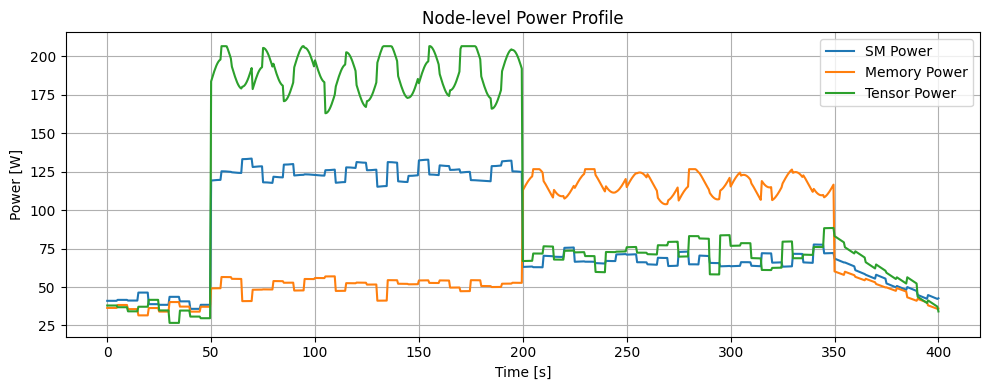

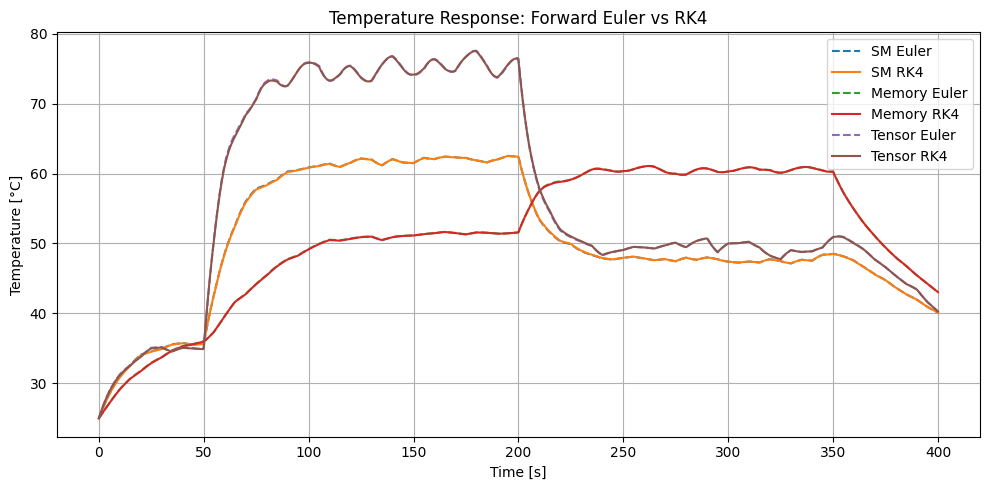

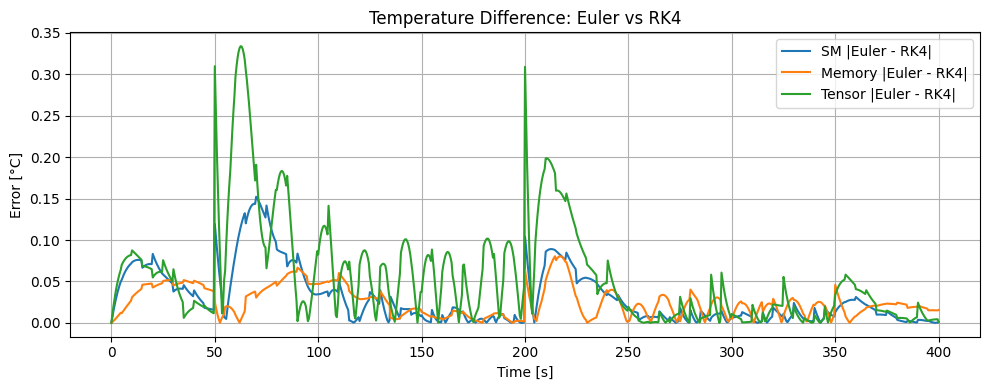

In [4]:
# Euler and RK4 Simulation
time_euler, T_euler, P_euler = simulate("euler", params)
time_rk4, T_rk4, P_rk4 = simulate("rk4", params)


# Error(Euler vs RK4)
error = T_euler - T_rk4
abs_error = np.abs(error)

rmse = np.sqrt(np.mean(error ** 2, axis=0))
max_error = np.max(abs_error, axis=0)
peak_temp_euler = np.max(T_euler, axis=0)
peak_temp_rk4 = np.max(T_rk4, axis=0)
peak_temp_diff = np.abs(peak_temp_euler - peak_temp_rk4)

for i, name in enumerate(node_names):
    print(f"[{name}]")
    print(f"  RMSE              : {rmse[i]:.6f} °C")
    print(f"  Max Error         : {max_error[i]:.6f} °C")
    print(f"  Peak Temp Euler   : {peak_temp_euler[i]:.6f} °C")
    print(f"  Peak Temp RK4     : {peak_temp_rk4[i]:.6f} °C")
    print(f"  Peak Temp Diff    : {peak_temp_diff[i]:.6f} °C")
    print()


# Power Profile
plt.figure(figsize=(10, 4))

for i, name in enumerate(node_names):
    plt.plot(time_euler, P_euler[:, i], label=f"{name} Power")

plt.title("Node-level Power Profile")
plt.xlabel("Time [s]")
plt.ylabel("Power [W]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Temperature Response
plt.figure(figsize=(10, 5))

for i, name in enumerate(node_names):
    plt.plot(time_euler, T_euler[:, i], linestyle="--", label=f"{name} Euler")
    plt.plot(time_rk4, T_rk4[:, i], linestyle="-", label=f"{name} RK4")

plt.title("Temperature Response: Forward Euler vs RK4")
plt.xlabel("Time [s]")
plt.ylabel("Temperature [°C]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Error
plt.figure(figsize=(10, 4))

for i, name in enumerate(node_names):
    plt.plot(time_euler, abs_error[:, i], label=f"{name} |Euler - RK4|")

plt.title("Temperature Difference: Euler vs RK4")
plt.xlabel("Time [s]")
plt.ylabel("Error [°C]")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
params_test = params.copy()
params_test["dt"] = 0.5

time_euler, T_euler, _ = simulate("euler", params_test)
time_rk4, T_rk4, _ = simulate("rk4", params_test)

params_ref = params.copy()
params_ref["dt"] = 0.01

time_ref, T_ref, _ = simulate("rk4", params_ref)

T_ref_interp = np.zeros_like(T_euler)

for node in range(T_euler.shape[1]):
    T_ref_interp[:, node] = np.interp(time_euler, time_ref, T_ref[:, node])

euler_error = T_euler - T_ref_interp
rk4_error = T_rk4 - T_ref_interp

euler_rmse = np.sqrt(np.mean(euler_error ** 2, axis=0))
rk4_rmse = np.sqrt(np.mean(rk4_error ** 2, axis=0))

euler_max_error = np.max(np.abs(euler_error), axis=0)
rk4_max_error = np.max(np.abs(rk4_error), axis=0)

for i, name in enumerate(node_names):
    print(f"[{name}]")
    print(f"  Euler RMSE vs Ref : {euler_rmse[i]:.6f} °C")
    print(f"  RK4 RMSE vs Ref   : {rk4_rmse[i]:.6f} °C")
    print(f"  Euler Max Error   : {euler_max_error[i]:.6f} °C")
    print(f"  RK4 Max Error     : {rk4_max_error[i]:.6f} °C")
    print()

[SM]
  Euler RMSE vs Ref : 0.056137 °C
  RK4 RMSE vs Ref   : 0.024107 °C
  Euler Max Error   : 0.195857 °C
  RK4 Max Error     : 0.130698 °C

[Memory]
  Euler RMSE vs Ref : 0.037423 °C
  RK4 RMSE vs Ref   : 0.014047 °C
  Euler Max Error   : 0.098154 °C
  RK4 Max Error     : 0.063267 °C

[Tensor]
  Euler RMSE vs Ref : 0.102796 °C
  RK4 RMSE vs Ref   : 0.045546 °C
  Euler Max Error   : 0.425033 °C
  RK4 Max Error     : 0.311069 °C

